 Section 1: Analytical Derivation [cite: 3]

## **Q1. Show that $x_{k}^{-} \sim \mathcal{N}(m_{k}^{-}, P_{k}^{-})$**
Given the state transition filter model equation:
$$x_{k}^{-} = A_{k-1}x_{k-1}^{+} + G_{k-1}w_{k-1}$$

Since the prior state $x_{k-1}^{+}$ and process noise $w_{k-1}$ are independent Gaussian random variables , their linear combination $x_{k}^{-}$ must also follow a Gaussian distribution. We derive its mean and covariance parameters below:

### **Expected Value (Mean):**
$$\begin{aligned}
m_{k}^{-} = \mathbb{E}[x_{k}^{-}] &= \mathbb{E}[A_{k-1}x_{k-1}^{+} + G_{k-1}w_{k-1}] \\
&= A_{k-1}\mathbb{E}[x_{k-1}^{+}] + G_{k-1}\mathbb{E}[w_{k-1}] \\
&= A_{k-1}m_{k-1} + G_{k-1}(0) \\
&= A_{k-1}m_{k-1}
\end{aligned}$$
This matches the predicted mean equation.

### **Covariance Matrix:**
$$\begin{aligned}
P_{k}^{-} = \text{Var}(x_{k}^{-}) &= \text{Var}(A_{k-1}x_{k-1}^{+} + G_{k-1}w_{k-1}) \\
&= A_{k-1}\text{Var}(x_{k-1}^{+})A_{k-1}^{T} + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^{T} \\
&= A_{k-1}P_{k-1}A_{k-1}^{T} + G_{k-1}\Sigma_{p}G_{k-1}^{T}
\end{aligned}$$
This satisfies the predicted covariance equation.

---

## **Q2. Show that $y_{k}^{-} \sim \mathcal{N}(H_{k}m_{k}^{-}, H_{k}P_{k}^{-}H_{k}^{T} + \Sigma_{m})$** Given the measurement model equation:
$$y_{k}^{-} = H_{k}x_{k}^{-} + z_{k}$$

### **Expected Value (Mean):**
$$\begin{aligned}
\mathbb{E}[y_{k}^{-}] &= \mathbb{E}[H_{k}x_{k}^{-} + z_{k}] \\
&= H_{k}\mathbb{E}[x_{k}^{-}] + \mathbb{E}[z_{k}] \\
&= H_{k}m_{k}^{-} + 0 \\
&= H_{k}m_{k}^{-}
\end{aligned}$$

### **Covariance Matrix:**
$$\begin{aligned}
\text{Var}(y_{k}^{-}) &= \text{Var}(H_{k}x_{k}^{-} + z_{k}) \\
&= H_{k}\text{Var}(x_{k}^{-})H_{k}^{T} + \text{Var}(z_{k}) \\
&= H_{k}P_{k}^{-}H_{k}^{T} + \Sigma_{m}
\end{aligned}$$
[cite_start]Thus, the measurement vector is distributed as $y_{k}^{-} \sim \mathcal{N}(H_{k}m_{k}^{-}, H_{k}P_{k}^{-}H_{k}^{T} + \Sigma_{m})$.

---

## **Q3. Show the Joint Distribution Matrix**
The combined state and measurement vector $\begin{bmatrix} x_{k}^{-} \\ y_{k}^{-} \end{bmatrix}$ forms a jointly Gaussian distribution[The joint mean vector is constructed directly by concatenating the individual means:
$$\mathbb{E}\begin{bmatrix} x_{k}^{-} \\ y_{k}^{-} \end{bmatrix} = \begin{bmatrix} m_{k^{-} \\ H_{k}m_{k}^{-} \end{bmatrix}$$

To compute the joint covariance block matrix, we analyze the cross-covariance component between $x_{k}^{-}$ and $y_{k}^{-}$:
$$\begin{aligned}
\text{Cov}(x_{k}^{-}, y_{k}^{-}) &= \mathbb{E}\left[(x_{k}^{-} - m_{k}^{-})(y_{k}^{-} - H_{k}m_{k}^{-})^{T}\right] \\
&= \mathbb{E}\left[(x_{k}^{-} - m_{k}^{-})(H_{k}(x_{k}^{-} - m_{k}^{-}) + z_{k})^{T}\right] \\
&= \mathbb{E}\left[(x_{k}^{-} - m_{k}^{-})(x_{k}^{-} - m_{k}^{-})^{T}\right]H_{k}^{T} + \mathbb{E}\left[(x_{k}^{-} - m_{k}^{-})z_{k}^{T}\right] \\
&= P_{k}^{-}H_{k}^{T} + 0 \\
&= P_{k}^{-}H_{k}^{T}
\end{aligned}$$

Because the cross-covariance is symmetric under transposition, $\text{Cov}(y_{k}^{-}, x_{k}^{-}) = \left(\text{Cov}(x_{k}^{-}, y_{k}^{-})\right)^{T} = H_{k}P_{k}^{-}$Assembling these blocks yields the target joint distribution matrix:
$$\begin{bmatrix} x_{k}^{-} \\ y_{k}^{-} \end{bmatrix} \sim \mathcal{N}\left(\begin{bmatrix} m_{k}^{-} \\ H_{k}m_{k}^{-} \end{bmatrix}, \begin{bmatrix} P_{k}^{-} & P_{k}^{-}H_{k}^{T} \\ H_{k}P_{k}^{-} & H_{k}P_{k}^{-}H_{k}^{T} + \Sigma_{m} \end{bmatrix}\right)$$

---

## **Q4. Show that $x_{k}^{+} \triangleq (x_{k}^{-} \mid y_{k}^{-} = y_{k}^{obs}) \sim \mathcal{N}(m_{k}, P_{k})$**Applying the **Gaussian Conditioning Theorem** to our joint distribution framework yields updates when an explicit measurement $y_{k}^{obs}$ is introduced. For any jointly Gaussian vectors $X$ and $Y$:
$$\mathbb{E}[X \mid Y=y] = \mu_X + \Sigma_{XY}\Sigma_{YY}^{-1}(y - \mu_Y)$$
$$\text{Var}(X \mid Y=y) = \Sigma_{XX} - \Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX}$$

Substituting our specific block components from Q3:
*$\mu_X = m_{k}^{-}$, $\mu_Y = H_{k}m_{k}^{-}$ $\Sigma_{XX} = P_{k}^{-}$, $\Sigma_{XY} = P_{k}^{-}H_{k}^{T}$, $\Sigma_{YY} = H_{k}P_{k}^{-}H_{k}^{T} + \Sigma_{m} = S_k$

By substituting the definitive Kalman Gain expression:
$$K_{k} = P_{k}^{-}H_{k}^{T}(H_{k}P_{k}^{-}H_{k}^{T} + \Sigma_{m})^{-1}$$

The resulting conditional expressions translate directly to the optimal filtered state update metrics:
$$m_{k} = m_{k}^{-} + K_{k}(y_{k}^{obs} - H_{k}m_{k}^{-})$$
$$P_{k} = P_{k}^{-} - K_{k}H_{k}P_{k}^{-} = (I - K_{k}H_{k})P_{k}^{-}$$

---

## **Q5. Find $\mathbb{E}[x_{k}^{-} \mid y_{k}^{-} = y_{k}^{obs}]$ and $\text{Var}(x_{k}^{-} \mid y_{k}^{-} = y_{k}^{obs})$** The conditional expectation and variance requested here are mathematically equivalent to evaluating the parameters of the posterior updated state vector distribution $(x_{k}^{-} \mid y_{k}^{-} = y_{k}^{obs})$Using our proofs from Q4, we get:

* **Conditional Expectation:**
  $$\mathbb{E}[x_{k}^{-} \mid y_{k}^{-} = y_{k}^{obs}] = m_{k} = m_{k}^{-} + K_{k}(y_{k}^{obs} - H_{k}m_{k}^{-})$$

* **Conditional Variance:**
  $$\text{Var}(x_{k}^{-} \mid y_{k}^{-} = y_{k}^{obs}) = P_{k} = (I - K_{k}H_{k})P_{k}^{-}$$

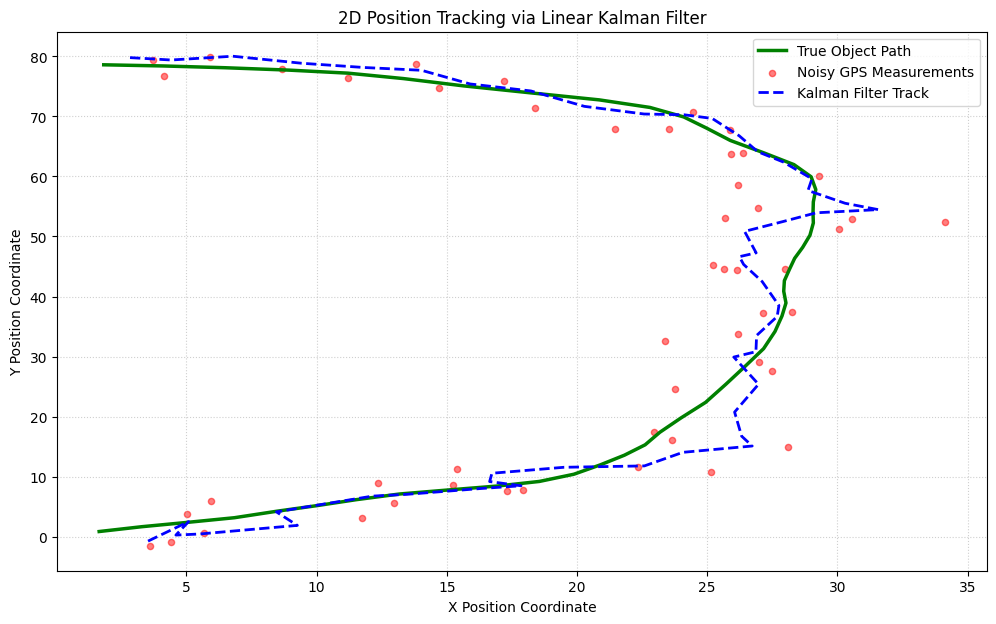

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialization and Parameter Configuration
dt = 1.0  # Time step interval
steps = 50

A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1, 0],
              [0, 0, 0, 1]])

G = np.array([[0.5 * dt**2, 0],
              [0, 0.5 * dt**2],
              [dt, 0],
              [0, dt]])

H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

# Noise variances
Sigma_p = np.eye(2) * 0.1   # Process noise covariance
Sigma_m = np.eye(2) * 5.0   # Measurement noise covariance (Noisy GPS)

# Allocate Trajectory Space
true_states = np.zeros((4, steps))
measurements = np.zeros((2, steps))

# Generate ground-truth trajectory and simulation data
x_true = np.array([0.0, 0.0, 1.5, 1.0])  # Initial state vector
for k in range(steps):
    w = np.random.multivariate_normal([0, 0], Sigma_p)
    x_true = A @ x_true + G @ w
    z = np.random.multivariate_normal([0, 0], Sigma_m)

    true_states[:, k] = x_true
    measurements[:, k] = H @ x_true + z

# 2. Complete Kalman Filtering Routine
est_states = np.zeros((4, steps))
m_est = np.array([0.0, 0.0, 0.0, 0.0])  # Prior mean guess
P_est = np.eye(4) * 10.0                # Prior uncertainty variance

for k in range(steps):
    # Time Prediction
    m_pred = A @ m_est
    P_pred = A @ P_est @ A.T + G @ Sigma_p @ G.T

    # Measurement Correction
    S = H @ P_pred @ H.T + Sigma_m
    K = P_pred @ H.T @ np.linalg.inv(S)

    y_obs = measurements[:, k]
    m_est = m_pred + K @ (y_obs - H @ m_pred)
    P_est = (np.eye(4) - K @ H) @ P_pred

    est_states[:, k] = m_est

# 3. Visualization Mapping
plt.figure(figsize=(12, 7))
plt.plot(true_states[0, :], true_states[1, :], 'g-', linewidth=2.5, label='True Object Path')
plt.scatter(measurements[0, :], measurements[1, :], color='red', alpha=0.5, s=20, label='Noisy GPS Measurements')
plt.plot(est_states[0, :], est_states[1, :], 'b--', linewidth=2, label='Kalman Filter Track')

plt.title("2D Position Tracking via Linear Kalman Filter")
plt.xlabel("X Position Coordinate")
plt.ylabel("Y Position Coordinate")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()